# Figure S13. Lifestyle benchmarks

In [1]:
### load packages
import glob

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
plt.rcParams.update({'font.size': 14})

In [ ]:
### Download checkv provirus info
# !wget https://portal.nersc.gov/UHGV/mysql/tsv/checkv_contamination.tsv
# !wget https://portal.nersc.gov/UHGV/mysql/tsv/genomad_viral_stats.tsv

--2026-01-19 12:20:25--  https://portal.nersc.gov/UHGV/mysql/tsv/genomad_viral_stats.tsv
Resolving portal.nersc.gov (portal.nersc.gov)... 128.55.206.110, 128.55.206.108, 128.55.206.107, ...
Connecting to portal.nersc.gov (portal.nersc.gov)|128.55.206.110|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 557789624 (532M) [text/tab-separated-values]
Saving to: ‘genomad_viral_stats.tsv’

genomad_viral_stats 100%[===================>] 531.95M  22.1MB/s    in 20s     

2026-01-19 12:20:45 (27.1 MB/s) - ‘genomad_viral_stats.tsv’ saved [557789624/557789624]



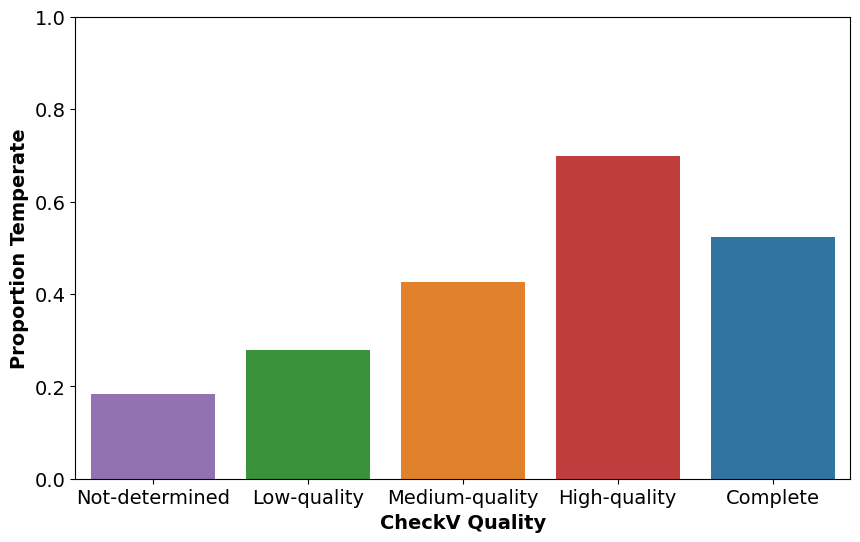

In [2]:
### UHGV prop temperate by completeness
conf_votus = (
    pl.read_csv('votus_metadata_extended.tsv', null_values='NULL', separator='\t', ignore_errors=True, columns=['uhgv_votu', 'bacphlip_temperate_score', 'uhgv_genome', 'checkv_quality', 'checkv_completeness', 'has_integrase', 'viral_confidence', 'lifestyle', 'lifestyle_evidence'])
)

checkv_provirus = (
    pl.read_csv('checkv_contamination.tsv', separator='\t', ignore_errors=True, null_values=['NULL'], columns=['contig_id', 'provirus', 'host_genes', 'host_length'])
        .rename({'contig_id':'uhgv_genome', 'provirus':'checkv_provirus'})
        .with_columns([
            pl.col('host_length').cast(pl.Float64)
        ])
)

genomad_provirus = (
    pl.read_csv('genomad_viral_stats.tsv', separator='\t', ignore_errors=True, columns=['contig_id', 'provirus'])
        .rename({'contig_id':'uhgv_genome', 'provirus':'genomad_provirus'})
)

contig2integrase = (
    pl.read_csv('../figure_s6/contig_to_integrase.tsv', separator='\t', ignore_errors=True)
)

combined = (
    conf_votus.join(checkv_provirus, on='uhgv_genome', how='left', coalesce=True).join(genomad_provirus, on='uhgv_genome', how='left', coalesce=True)
        .group_by(pl.col('checkv_quality'))
        .agg([
            (pl.col('lifestyle') != 'lytic').sum().alias('num_temperate'),
            pl.len().alias('total')
        ])
        .with_columns([
            (pl.col('num_temperate') / pl.col('total')).alias('prop_temperate')
        ])
)

# plot prop temperate by quality category
# make figure wider
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=combined,
    x='checkv_quality',
    y='prop_temperate',
    hue='checkv_quality',
    order=['Not-determined', 'Low-quality', 'Medium-quality', 'High-quality', 'Complete']
)

ax.set_xlabel('CheckV Quality', fontdict={'fontweight': 'bold'})
ax.set_ylabel('Proportion Temperate', fontdict={'fontweight': 'bold'})
ax.set_ylim(0, 1)
plt.show()

In [3]:
### Load UHGV lifestyle info for HQ votu reps
uhgv_lifestyle = (
    conf_votus
        .join(checkv_provirus, on='uhgv_genome', how='left', coalesce=True)
        .join(genomad_provirus, on='uhgv_genome', how='left', coalesce=True)
        .filter(pl.col('viral_confidence') == 'Confident')
        .filter(pl.col('checkv_completeness') >= 90)
)
uhgv_lifestyle.height

57514

In [4]:
### Count number of UHGV viruses classified as temperate by each method
# load uhvdb classifications
uhvdb_lifestyles = (
    pl.read_csv('../figure_1/uhgv_hq_hc_results/2026-03-11/uhvdb/lifestyle/uhvdb_lifestyle/bacphlip.lifestyle.tsv.gz', separator='\t')
)

# load mapping file
mapping = (
    pl.read_csv('../figure_1/uhgv_hq_hc_results/2026-03-11_outputs/rename/hq_hc_viruses/hq_hc_viruses.id_mapping.tsv.gz', separator='\t', ignore_errors=True, has_header=False)
        .with_columns([
            pl.col('column_1').str.replace(r'\|provirus.*', '')
        ])
)

uhvdb_lifestyles = (
    uhvdb_lifestyles
        .join(mapping, left_on='seq_name', right_on='column_2', how='inner')
)

# join uhgv with uhvdb data
uhgv_uhvdb_joined = (
    uhvdb_lifestyles
        .join(mapping, left_on='seq_name', right_on='column_2', how='inner')
        .join(uhgv_lifestyle, left_on='column_1', right_on='uhgv_genome', how='inner', suffix='_uhgv')
)

uhgv_uhvdb_joined.height

50369

In [19]:
uhgv_uhvdb_joined = (
    uhvdb_lifestyles
        .join(mapping, left_on='seq_name', right_on='column_2', how='inner')
        .join(genomad_provirus, left_on='column_1', right_on='uhgv_genome', how='inner')
)


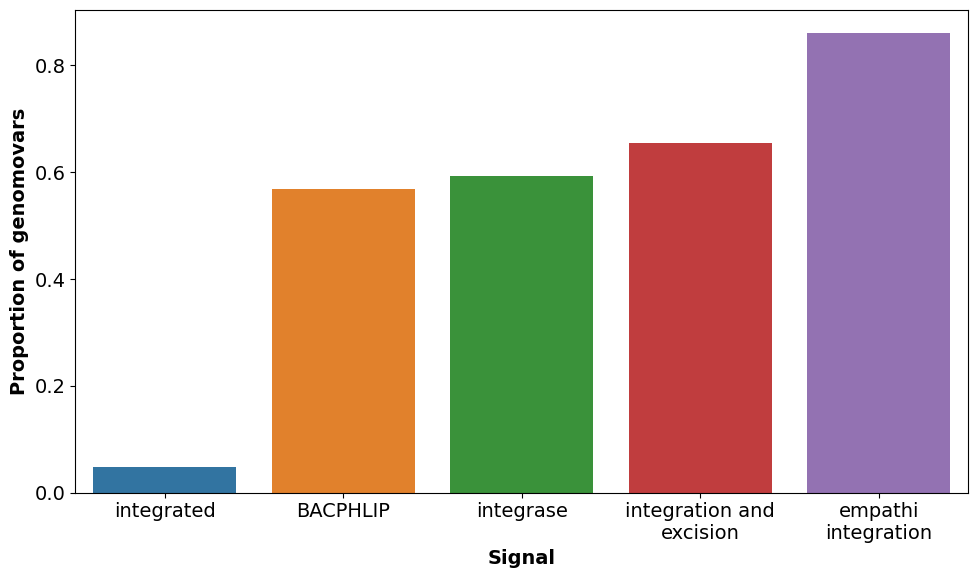

In [31]:
### Barplot: count of temperate signals in uhgv_uhvdb_joined
cols = set(uhgv_uhvdb_joined.columns)

signal_counts = pl.DataFrame({
    'signal': [
        'integrated',
        'BACPHLIP',
        'integrase',
        'integration and\nexcision',
        'empathi\nintegration'
    ],
    'count': [
        uhgv_uhvdb_joined.filter(pl.col('genomad_provirus') == 'Yes').height / uhgv_uhvdb_joined.height,
        uhgv_uhvdb_joined.filter(pl.col('temperate') > 0.5).height / uhgv_uhvdb_joined.height,
        uhgv_uhvdb_joined.filter(pl.col('phrog_integrases') >= 1).height / uhgv_uhvdb_joined.height,
        uhgv_uhvdb_joined.filter(pl.col('phrog_integration_excision') >= 1).height / uhgv_uhvdb_joined.height,
        uhgv_uhvdb_joined.filter(pl.col('empathi_integration') >= 1).height / uhgv_uhvdb_joined.height
    ]
})

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=signal_counts.to_pandas(),
    x='signal',
    y='count',
    hue='signal',
    dodge=False,
    ax=ax
)

ax.set_xlabel('Signal', fontdict={'fontweight': 'bold'})
ax.set_ylabel('Proportion of genomovars', fontdict={'fontweight': 'bold'})
plt.tight_layout()
plt.show()

In [15]:
### Compare proportion of viruses classified as temperate by three methods
temperate_classifications = (
    uhgv_uhvdb_joined
        .with_columns([
            (
                ((pl.col('checkv_provirus') == 'Yes')).fill_null(False).cast(pl.Int32) +
                ((pl.col('temperate') > 0.5)).fill_null(False).cast(pl.Int32) +
                ((pl.col('phrog_integration_excision') >= 1) | (pl.col('empathi_integration') >= 1)).fill_null(False).cast(pl.Int32)
            ).alias('temperate_signal_count')
        ])
)

total_viruses = temperate_classifications.height

temperate_proportions = pl.DataFrame({
    'method': [
        "UHGV temperate",
        '2+ UHVDB\ntemperate signals',
        '1+ UHVDB\ntemperate signals'
    ],
    'temperate_count': [
        temperate_classifications.filter(pl.col('lifestyle') == 'temperate').height,
        temperate_classifications.filter(pl.col('temperate_signal_count') >= 2).height,
        temperate_classifications.filter(pl.col('temperate_signal_count') >= 1).height
    ]
}).with_columns([
    (pl.col('temperate_count') / total_viruses).alias('proportion')
])

temperate_proportions

method,temperate_count,proportion
str,i64,f64
"""UHGV temperate""",32099,0.637277
"""2+ UHVDB temperate signals""",31915,0.633624
"""1+ UHVDB temperate signals""",39960,0.793345


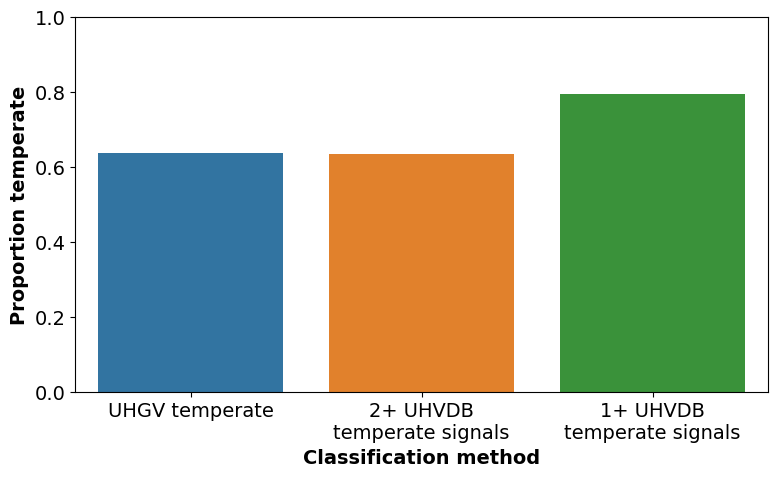

In [16]:
### Barplot of temperate classification proportions
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=temperate_proportions.to_pandas(),
    x='method',
    y='proportion',
    hue='method',
    dodge=False,
    ax=ax
 )

ax.set_xlabel('Classification method', fontdict={'fontweight': 'bold'})
ax.set_ylabel('Proportion temperate', fontdict={'fontweight': 'bold'})
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [31]:
### Figure S15C: UHVDB temperate counts by method
# # Download genomad stats file
# !wget https://portal.nersc.gov/cfs/m342/UHGV/mysql/tsv/genomad_viral_stats.tsv

uhgv_proviruses = set(
    pl.read_csv('../figure_4/genomad_viral_stats.tsv', separator='\t', columns=['contig_id', 'provirus'])
    .filter(pl.col('provirus') == "Yes")
    ['contig_id']
)

### get OPD provirus info
# 1. download Excel sheet with metadata: https://static-content.springer.com/esm/art%3A10.1038%2Fs41522-025-00773-z/MediaObjects/41522_2025_773_MOESM2_ESM.xlsx
# 2. Filter Table3-OPD quality to identify 'replace_id' with 'checkv_provirus' == "Yes"
# 3. Save as TSV: opd_checkv_proviruses.tsv
opd_proviruses = set(
    pl.read_csv('../figure_4/opd_checkv_provirus.tsv', separator='\t', columns=['replace_id'])
    ['replace_id']
)

### Get CNGVC integration information
# CNGVC did not perform host trimming, so just used UHVDB provirus info

#### get CGVR provirus info
# 1. CGVR metadata downloaded from: https://static-content.springer.com/esm/art%3A10.1186%2Fs40168-025-02185-9/MediaObjects/40168_2025_2185_MOESM1_ESM.xlsx
# 2. Filter Table S1 to identify 'Viral_bin_id' with 'provirus' == "Yes"
# 3. Save as TSV: cgvr_checkv_proviruses.tsv
cgvr_proviruses = set(
    pl.read_csv('../figure_4/cgvr_checkv_proviruses.tsv', separator='\t', columns=['Viral_bin_id'])
    ['Viral_bin_id']
)

### get IMGVR integration info
# 1. Download IMGVR metadata from: https://genome.jgi.doe.gov/portal/pages/dynamicOrganismDownload.jsf?organism=IMG_VR
imgvr_proviruses = set(
    pl.read_csv('../figure_1/IMGVR_all_Sequence_information.tsv', separator='\t', columns=['UVIG', 'Topology'])
        .filter(pl.col('Topology') == 'Provirus')
        ['UVIG']
)

### get mMGE provirus info
# 1. Download mMGE metadata from: https://mai.fudan.edu.cn/mgedb/client/file/all_mge_inf.zip
mmge_proviruses = set(
    pl.read_csv('../figure_1/all_mge_inf.csv')
        .filter(pl.col('prophage') == True)
        ['MGEs_id']
)

### load UHVDB r2025_09 info to identify Complete vs HQ viruses
uhvdb_info = (
    pl.read_csv(
        '../figure_2/vclust/uhvdb_vclust_cluster_info_final.tsv',
        separator='\t', columns=['contig_id', 'completeness_method', 'votu_rep']
    )
)

# identify species reps
species_reps = set(
    uhvdb_info['votu_rep']
)

In [42]:
# combine all provirus sets
integrated_union = set(
    uhvdb_info
        .filter(
            pl.col('contig_id').is_in(
                uhgv_proviruses.union(
                    opd_proviruses
                ).union(
                    cgvr_proviruses
                ).union(
                    imgvr_proviruses
                ).union(
                    mmge_proviruses
                )
            ) |
            (pl.col('contig_id').str.contains('provirus'))
        )
        .filter(pl.col('contig_id').is_in(species_reps))
        ['contig_id']
)
print(f"Total UHVDB integrated genomes: {len(integrated_union)}")

Total UHVDB integrated genomes: 24007


In [32]:
# count of viruses with bacphlip score > 0.5
### load bacphlip results for UHVDB r2025_09
bacphlip_lst = []
for file in glob.glob('../figure_4/uhvdb_genomovar_chunks/*.fna.bacphlip'):
    df = (
        pl.read_csv(file, separator='\t', null_values=['NA'], new_columns=['contig_id', 'virulent', 'temperate'])
    )
    bacphlip_lst.append(df)

In [37]:
bacphlip_temp = set(
    pl.concat(bacphlip_lst)
        .filter(pl.col('contig_id').is_in(species_reps))
        .filter(pl.col('temperate') > 0.5)
        ['contig_id']
)

In [35]:
pharokka_dir = "../figure_4/function/tmp/2026_01_08/annotate/function/pharokka/pharokka/*.fna/*.tsv.gz"
pharokka_lst = []
for file in glob.glob(pharokka_dir):
    try:
        df = (
            pl.read_csv(file, separator='\t', ignore_errors=True, columns=['gene', 'contig', 'custom_hmm_id', 'annot'])
                .filter(
                    (pl.col('annot').str.contains('integrase')) |
                    (pl.col('annot').str.contains('recombinase'))
                )
        )
        pharokka_lst.append(df)
    except pl.exceptions.NoDataError:
        continue

pharokka_df = (
    pl.concat(pharokka_lst)
    .with_columns([pl.col('contig').str.replace('uhvdb_votu_reps.fna_', '')])
    .filter(pl.col('contig').is_in(species_reps))
)

In [36]:
phold_dir = "../figure_4/function/tmp/2026_01_08/annotate/function/phold/compare/*.fna/*.fna.phold.tsv.gz"
phold_lst = []
for file in glob.glob(phold_dir):
    try:
        df = (
            pl.read_csv(file, separator='\t', ignore_errors=True, columns=['contig_id', 'cds_id', 'phrog', 'product'], schema_overrides={'phrog': pl.Utf8, 'function': pl.Utf8, 'product': pl.Utf8})
                .filter(
                    (pl.col('product').str.contains('integrase')) |
                    (pl.col('product').str.contains('recombinase'))
                )
        )
        phold_lst.append(df)
    except pl.exceptions.NoDataError:
        continue

phold_df = (
    pl.concat(phold_lst)
    .with_columns([pl.col('contig_id').str.replace('uhvdb_votu_reps.fna_', '')])
    .filter(pl.col('contig_id').is_in(species_reps))
)

In [41]:
# create set from union of pharokka and phold
pharokka_proviruses = set(
    pharokka_df['contig']
)
phold_proviruses = set(
    phold_df['contig_id']
)
integrase_union = (
    pharokka_proviruses.union(phold_proviruses)
)

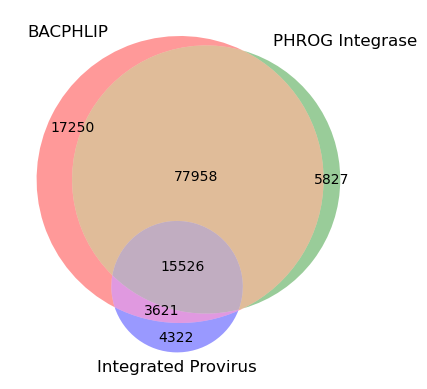

In [45]:
# create a venn diagram of the number of temperate phages in bacphlip_temp, integrase_union, and integrated_union
from matplotlib_venn import venn3

# create venn diagram
venn3(
    subsets = (
        len(bacphlip_temp - integrase_union - integrated_union),            # Only Bacphlip
        len(integrase_union - bacphlip_temp - integrated_union),            # Only Integrase
        len(bacphlip_temp & integrase_union - integrated_union),            # Bacphlip & Integrase
        len(integrated_union - bacphlip_temp - integrase_union),            # Only Integrated
        len(bacphlip_temp & integrated_union - integrase_union),            # Bacphlip & Integrated
        len(integrase_union & integrated_union - bacphlip_temp),            # Integrase & Integrated
        len(bacphlip_temp & integrase_union & integrated_union)             # All three
    ),
    set_labels = ('BACPHLIP', 'PHROG Integrase', 'Integrated Provirus')
)
plt.show()
